# Transformer

## 0. Введение

Мы познакомимся с моделью **Transformer** на практической задаче **анализа тональности текста**.

Мы будем работать с датасетом [`IMDB Dataset of 50K Movie Reviews`](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews) &mdash; это 50 000 отзывов на фильмы,
размеченных как `positive` или `negative`.

**Цель:** по тексту отзыва автоматически определить его эмоциональную окраску. Таким обазом, мы решаем задачу бинарной классификации.


### Пример данных

```text
MYSTERY MEN has got to be THE stupidest film I've ever seen, but
what a film!I thought it was fabulous, excellent and impressive.
It was funny, well-done and nice to see ridiculous Super Heroes
for a change! And being able to pull it off! This was great!
I'll definitely watch it again!
```
**Метка:** `positive`

```text
We brought this film as a joke for a friend, and could of been
our worst joke to play. The film is barely watchable, and the
acting is dire. The worst child actor ever used and Hasslehoff
giving a substandard performance. The plot is disgraceful and at
points we was so bored we was wondering what the hell was going
on. It tries to be gruesome in places but is just laughable.
Just terrible
```
**Метка:** `negative`

### Почему простые модели работают плохо?

Вспомним ранее изученные подходы:
- **Статические методы** (Bag of Words / TF-IDF) &mdash; не учитывают порядок и контекст слов.
- **RNN** &mdash; теряют информацию на длинных текстах.

Во всех этих моделях сложно эффективно учитывать дальние зависимости в тексте.

На этом семинаре мы рассмотрим модель **Transformer**, использующую механизм **Self-Attention**, который позволяет:
- учитывать контекст целиком,
- фокусироваться на важных словах независимо от расстояния
- эффективно обрабатывать длинные тексты

Поэтому трансформеры стали стандартом для современных NLP-задач.

Сначала подробно рассмотрим работу модели на простом примере, а потом перейдём к исходной задаче.

In [ ]:
from tqdm.notebook import tqdm
from collections import defaultdict

import numpy as np
import pandas as pd
import seaborn as sns
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score

import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

from datasets import load_dataset

from transformers import BertTokenizer, BertConfig, DataCollatorWithPadding
from transformers import BertModel, BertForSequenceClassification

from IPython.display import clear_output

from pprint import pprint

sns.set(font_scale=1.2)
sns.set_style(style='darkgrid')
device_num = 0

device = "mps" if torch.backends.mps.is_available() else f"cuda:{device_num}" if torch.cuda.is_available() else "cpu"

В этом ноутбуке мы разберёмся, как работает архитектура Transformer, проследив путь данных от входа до выхода, и напишем свою реализацию с нуля.

## 1. Архитектура модели

### 1.1. Высокоуровневый взгляд на модель

Трансформер &mdash; это архитектура seq2seq. Для начала представим его как черный ящик: мы подаем предложение на одном языке, а на выходе получаем перевод.

![](https://jalammar.github.io/images/t/the_transformer_3.png)

Если заглянуть внутрь архитектуры, мы увидим два основных блока:

* **Encoder**  
  Читает входную последовательность (например, *"Je suis étudiant"*) и преобразует её в последовательность скрытых векторных представлений.  
  Каждый слой энкодера:
  - обрабатывает **всю последовательность целиком**, а не по шагам;
  - уточняет представление каждого токена с учётом **контекста всех остальных токенов** через механизм self-attention;
  - сохраняет длину последовательности, но меняет содержание векторов &mdash; они становятся контекстно-зависимыми.

  Итогом работы последовательности энкодеров является набор векторов. Важно подчеркнуть, что это **не один сжатый вектор**, а последовательность представлений &mdash; по одному на каждый входной токен.

* **Decoder**  
  Генерирует выходную последовательность (например, *"I am a student"*) **токен за токеном**, используя:
  - уже сгенерированные ранее токены (masked self-attention);
  - выходы энкодера в качестве внешнего контекста (cross-attention).

  Каждый слой декодера на схеме получает доступ **ко всем выходам энкодера** &mdash; это показано веером стрелок. Таким образом, на каждом шаге генерации модель может выборочно "сфокусироваться" на разных частях входного предложения.


В оригинальной статье ["Attention is All You Need"](https://arxiv.org/abs/1706.03762) используется 6 слоев в энкодере и 6 &mdash; в декодере. Это число не является принципиальным ограничением архитектуры, а отражает компромисс между качеством модели и вычислительной сложностью. В современных моделях трансформеров количество слоёв может доходить до десятков и даже сотен, сохраняя при этом ту же самую структурную схему.

![](https://jalammar.github.io/images/t/The_transformer_encoder_decoder_stack.png)

### 1.2. Входные данные

Трансформер не обрабатывает текст как последовательность во времени (в отличие от RNN).  
Он **"смотрит" на всё предложение целиком**, обрабатывая все токены параллельно.  
Из-за этого в самой архитектуре отсутствует встроенное понятие порядка слов.

Чтобы модель знала, **какой токен на какой позиции стоит**, к обычным эмбеддингам слов добавляются специальные векторы &mdash; **Positional Encodings (PE)**.

Для каждого входного токена из примера (*Je*, *suis*, *étudiant*) происходит следующее:

1. Сначала токен переводится в **векторное представление** (embedding) размерности `d`.
2. Для его позиции в предложении вычисляется **PE** той же размерности.
3. Эти два вектора **складываются поэлементно**.
4. Уже эта сумма подаётся на вход **первого слоя энкодера**.

В оригинальной статье по трансформерам positional encodings задаются формулой через синусы и косинусы разных частот:

$$
p_{2j} = \sin\left(\frac{pos}{10000^{2j / d}}\right)
$$

$$
p_{2j+1} = \cos\left(\frac{pos}{10000^{2j / d}}\right)
$$

где:
- $pos$ &mdash; позиция токена в последовательности,
- $j$ &mdash; индекс элемента в последовательности,
- $d$ &mdash; размерность эмбеддингов модели.

Стоит заметить, что такие PE **не требуют обучения**, а значит, позволяют модели **обобщаться на длины последовательностей**, которых не было во время обучения.

![](https://jalammar.github.io/images/t/transformer_positional_encoding_vectors.png)

Реализуем PE как класс `nn.Module`.

In [ ]:
class PositionalEncoding(nn.Module):
    """
    Реализация позиционного кодирования для трансформерных моделей.

    Добавляет к входным эмбеддингам информацию о позиции токенов в последовательности.
    """

    def __init__(self, d_model: int, max_len: int = 5000) -> None:
        """
        Инициализирует позиционное кодирование.

        Args:
            d_model: Размерность эмбеддингов.
            max_len: Максимальная длина последовательности.

        Returns:
            None
        """
        super().__init__()
        # Создаем матрицу [max_len, d_model] с PE
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # unsqueeze для добавления размерности батча: [1, max_len, d_model]
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Добавляет позиционное кодирование к входным эмбеддингам.

        Args:
            x: Тензор эмбеддингов формы [batch_size, seq_len, d_model].

        Returns:
            Тензор эмбеддингов с добавленным позиционным кодированием.
        """
        # x: [batch_size, seq_len, d_model]
        # Добавляем позиционную информацию к эмбеддингам
        x = x + self.pe[:, :x.size(1), :]
        return x


### 1.3. Механизм Self-Attention

Это ключевая часть трансформера. Когда модель смотрит на слово "банка" в предложении "В банке были различные соления.", она должна понять, что речь о стеклянной ёмкости, а не о финансах. Self-Attention позволяет каждому слову "посмотреть" на другие слова в предложении и понять контекст.

Для каждого слова мы создаем три вектора:
- $Q$ &mdash; **Query**: "Запрос" — что мы ищем?
- $K$ &mdash; **Key**: "Ключ" — метка содержания (как ключ в словаре).
- $V$ &mdash; **Value**: "Значение" — сама информация.

Мы считаем "похожесть" (*score*) между $Q$ текущего слова и $K$ всех остальных слов через скалярное произведение.

Классическая формула Scaled Dot-Product Attention:

$$ Attention(Q,K,V) = softmax \left( \frac{​​Q K^T}{\sqrt{d_k}} \right) \cdot V $$

![](https://jalammar.github.io/images/t/self-attention-output.png)

Теперь рассмотрим **Multi-Head Self-Attention**. Основная идея в том, что описанный выше алгоритм self-attention выполняется **несколько раз параллельно** &mdash; это позволяет модели одновременно фокусироваться на **разных типах зависимостей** между токенами.

Этот механизм работает следующим образом:

**1. Входная последовательность**  
На вход слоя поступает матрица:
- $X \in \mathbb{R}^{T \times d_{model}}$ &mdash; для первого энкодера (эмбеддинги + positional encoding), где $T$ &mdash; длина последовательности,
- $R$ &mdash; для всех последующих энкодеров (выход предыдущего слоя).

**2. Линейные проекции в Q, K, V**  
Для каждой головы `h` используются **свои обучаемые матрицы**: $W_{hQ}$, $W_{hK}$, $W_{hV}$.

Проекции считаются как:
$$
Q_h = X W_{hQ},\quad K_h = X W_{hK},\quad V_h = X W_{hV}
$$

То есть каждая голова видит **один и тот же X**, но проецирует его в **разные подпространства**.

**3. Параллельное вычисление attention в головах**

Для каждой головы независимо считается scaled dot-product attention:
$$
\text{Attention}(Q_h, K_h, V_h)
= \text{softmax}\left(\frac{Q_h K_h^\top}{\sqrt{d_k}}\right)V_h
$$

Результат — матрица $Z_h$, где каждая строка &mdash; это новый контекстный вектор токена, полученный с учётом всех остальных токенов в последовательности.

**4. Конкатенация голов**

Все выходы голов **склеиваются по размерности признаков**:
$$
Z = \text{Concat}(Z_0, Z_1, \dots, Z_{H-1})
$$

**5. Финальная линейная проекция**

Полученная матрица умножается на общую матрицу $Z W^O$.

Эта операция:
1. смешивает информацию из разных голов,
2. возвращает представление в пространство размерности модели,
3. формирует **выход multi-head attention слоя**.

![](https://jalammar.github.io/images/t/transformer_multi-headed_self-attention-recap.png)

Реализуем эту часть.

In [ ]:
class MultiHeadAttention(nn.Module):
    """
    Реализация Multi-Head Attention.

    Выполняет параллельное внимание по нескольким головам и объединяет результат.
    """

    def __init__(self, d_model: int, num_heads: int) -> None:
        """
        Инициализирует модуль многоголового внимания.

        Args:
            d_model: Размерность входных и выходных эмбеддингов.
            num_heads: Количество голов внимания.

        Returns:
            None
        """
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_k = torch.tensor(d_model // num_heads)
        self.num_heads = num_heads

        # Линейные слои для проекции Q, K, V
        self.linear_q = nn.Linear(d_model, d_model)
        self.linear_k = nn.Linear(d_model, d_model)
        self.linear_v = nn.Linear(d_model, d_model)

        self.linear_out = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(
        self,
        Q: torch.Tensor,
        K: torch.Tensor,
        V: torch.Tensor,
        mask: torch.Tensor | None = None
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Вычисляет масштабированное скалярное произведение Attention.

        Args:
            Q: Запросы формы [batch_size, num_heads, seq_len, d_k].
            K: Ключи формы [batch_size, num_heads, seq_len, d_k].
            V: Значения формы [batch_size, num_heads, seq_len, d_k].
            mask: Опциональная маска внимания.

        Returns:
            Кортеж из:
            - выходного тензора внимания,
            - весов внимания.
        """
        # Q, K, V: [batch_size, num_heads, seq_len, d_k]

        # 1. Matmul Q * K_transposed
        scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(self.d_k)

        # 2. Применяем маску (если есть), зануляя значения (ставим -inf)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # 3. Softmax
        attn_weights = torch.softmax(scores, dim=-1)

        # 4. Matmul weights * V
        output = torch.matmul(attn_weights, V)
        return output, attn_weights

    def forward(
        self,
        q: torch.Tensor,
        k: torch.Tensor,
        v: torch.Tensor,
        mask: torch.Tensor | None = None
    ) -> torch.Tensor:
        """
        Применяет Multi-Head Attention к входным тензорам.

        Args:
            q: Тензор запросов формы [batch_size, seq_len, d_model].
            k: Тензор ключей формы [batch_size, seq_len, d_model].
            v: Тензор значений формы [batch_size, seq_len, d_model].
            mask: Опциональная маска внимания.

        Returns:
            Тензор результата внимания формы [batch_size, seq_len, d_model].
        """
        batch_size = q.size(0)

        # Проекция и разделение на головы
        # shape: [batch, seq_len, d_model] -> [batch, seq_len, heads, d_k] -> [batch, heads, seq_len, d_k]
        Q = self.linear_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.linear_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.linear_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Применяем Attention
        output, attn_weights = self.scaled_dot_product_attention(Q, K, V, mask)

        # Объединяем головы обратно (Concat)
        # shape: [batch, heads, seq_len, d_k] -> [batch, seq_len, heads, d_k] -> [batch, seq_len, d_model]
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.num_heads * self.d_k)

        return self.linear_out(output)


### 1.4. Слои Encoder и Decoder

#### 1.4.1. Encoder

Каждый слой трансформера, помимо блока MHSA, содержит ещё два важных компонента:
**Feed Forward сеть** и **Residual Connections с Layer Normalization**.  
Именно их сочетание делает глубокие трансформеры стабильными и обучаемыми.

##### Feed Forward Network (FFN)

После блока multi-head attention каждый токен **независимо от других** проходит через одинаковую двухслойную полносвязную сеть.

Можно сказать, что:
- attention отвечает на вопрос *"откуда брать информацию?"*,
- FFN &mdash; *"как её преобразовать?"*.

##### Residual Connections (Skip Connections)

Каждый подблок (attention и FFN) обёрнут в residual-connection.

Что это даёт:
- облегчает прохождение градиентов через глубокую сеть,
- позволяет слою **модифицировать представление**, а не пересчитывать его с нуля,
- делает обучение стабильным при десятках слоёв.

##### Layer Normalization

После сложения применяется **Layer Normalization**.

Важные особенности:
- нормализация происходит **по признакам**, а не по батчу, в отличие от BatchNorm,
- одинаково работает для любой длины последовательности,
- снижает внутренний covariate shift и ускоряет обучение.

![](https://jalammar.github.io/images/t/transformer_resideual_layer_norm_2.png)

In [ ]:
class PositionwiseFeedForward(nn.Module):
    """
    Позиционно-независимый полносвязный feed-forward слой.

    Применяется отдельно к каждому элементу последовательности.
    """

    def __init__(self, d_model: int, d_ff: int) -> None:
        """
        Инициализирует feed-forward слой.

        Args:
            d_model: Размерность входных и выходных эмбеддингов.
            d_ff: Размерность скрытого слоя.

        Returns:
            None
        """
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Применяет feed-forward преобразование к входному тензору.

        Args:
            x: Входной тензор формы [batch_size, seq_len, d_model].

        Returns:
            Выходной тензор формы [batch_size, seq_len, d_model].
        """
        return self.fc2(self.relu(self.fc1(x)))


class EncoderLayer(nn.Module):
    """
    Один слой энкодера трансформера.

    Состоит из self-attention и feed-forward подслоёв с residual-связями и нормализацией.
    """

    def __init__(
        self,
        d_model: int,
        num_heads: int,
        d_ff: int,
        dropout: float = 0.1
    ) -> None:
        """
        Инициализирует слой энкодера.

        Args:
            d_model: Размерность эмбеддингов.
            num_heads: Количество голов внимания.
            d_ff: Размерность feed-forward слоя.
            dropout: Вероятность dropout.

        Returns:
            None
        """
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,
        mask: torch.Tensor | None = None
    ) -> torch.Tensor:
        """
        Применяет один слой энкодера к входной последовательности.

        Args:
            x: Входной тензор формы [batch_size, seq_len, d_model].
            mask: Опциональная маска внимания.

        Returns:
            Выходной тензор формы [batch_size, seq_len, d_model].
        """
        # Sublayer 1: Self-Attention + Add & Norm
        attn_out = self.self_attn(x, x, x, mask)  # q=x, k=x, v=x
        x = self.norm1(x + self.dropout(attn_out))

        # Sublayer 2: Feed Forward + Add & Norm
        ff_out = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x


#### 1.4.2. Decoder

Декодер отличается тем, что:
1. Имеет **Masked Self-Attention**: Нельзя "подглядывать" в будущие слова при генерации.
2. Имеет **Encoder-Decoder Attention**: *Query* идет из декодера, а *Key* и *Value* &mdash; из выхода энкодера.

![](https://jalammar.github.io/images/t/transformer_decoding_2.gif)

In [ ]:
class DecoderLayer(nn.Module):
    """
    Один слой декодера трансформера.

    Состоит из masked self-attention, encoder-decoder attention и feed-forward подслоёв
    с residual-связями и нормализацией.
    """

    def __init__(
        self,
        d_model: int,
        num_heads: int,
        d_ff: int,
        dropout: float = 0.1
    ) -> None:
        """
        Инициализирует слой декодера.

        Args:
            d_model: Размерность эмбеддингов.
            num_heads: Количество голов внимания.
            d_ff: Размерность feed-forward слоя.
            dropout: Вероятность dropout.

        Returns:
            None
        """
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)  # Cross Attention
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,
        enc_output: torch.Tensor,
        src_mask: torch.Tensor,
        tgt_mask: torch.Tensor
    ) -> torch.Tensor:
        """
        Применяет один слой декодера к входной последовательности.

        Args:
            x: Входной тензор декодера формы [batch_size, tgt_seq_len, d_model].
            enc_output: Выход энкодера формы [batch_size, src_seq_len, d_model].
            src_mask: Маска для encoder-decoder attention.
            tgt_mask: Маска для masked self-attention в декодере.

        Returns:
            Выходной тензор формы [batch_size, tgt_seq_len, d_model].
        """
        # 1. Masked Self-Attention
        attn_out = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_out))

        # 2. Encoder-Decoder Attention (Q=x, K=enc, V=enc)
        attn_out = self.enc_dec_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_out))

        # 3. Feed Forward
        ff_out = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_out))
        return x

### 1.5. Сборка всего трансформера

Осталось собрать всё в один класс. Нам понадобятся маски:
- `src_mask`: Чтобы игнорировать padding-токены во входе.
- `tgt_mask`: Чтобы игнорировать padding и будущие токены в выходе.

In [ ]:
class Transformer(nn.Module):
    """
    Полная модель трансформера для sequence-to-sequence задач.

    Состоит из энкодера, декодера и выходного линейного слоя.
    """

    def __init__(
        self,
        src_vocab_size: int,
        tgt_vocab_size: int,
        d_model: int,
        num_heads: int,
        num_layers: int,
        d_ff: int,
        max_len: int,
        dropout: float = 0.1
    ) -> None:
        """
        Инициализирует модель трансформера.

        Args:
            src_vocab_size: Размер словаря входной последовательности.
            tgt_vocab_size: Размер словаря выходной последовательности.
            d_model: Размерность эмбеддингов.
            num_heads: Количество голов внимания.
            num_layers: Количество слоёв энкодера и декодера.
            d_ff: Размерность feed-forward слоя.
            max_len: Максимальная длина последовательности.
            dropout: Вероятность dropout.

        Returns:
            None
        """
        super().__init__()

        self.d_model = torch.tensor(d_model)

        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.pe = PositionalEncoding(d_model, max_len)

        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )
        self.decoder_layers = nn.ModuleList(
            [DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )

        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(
        self,
        src: torch.Tensor,
        tgt: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Генерирует маски для энкодера и декодера.

        Args:
            src: Входная последовательность формы [batch_size, src_len].
            tgt: Целевая последовательность формы [batch_size, tgt_len].

        Returns:
            Кортеж из:
            - маски для энкодера,
            - маски для декодера.
        """
        # src: [batch, src_len]
        # tgt: [batch, tgt_len]

        # Маска для src (игнорируем 0 - padding)
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2)  # [batch, 1, 1, src_len]

        # Маска для tgt (padding + look ahead)
        tgt_pad_mask = (tgt != 0).unsqueeze(1).unsqueeze(2)  # [batch, 1, 1, tgt_len] - для broadcasting

        seq_len = tgt.size(1)
        nopeak_mask = (1 - torch.triu(torch.ones(1, seq_len, seq_len), diagonal=1)).bool().to(tgt.device)
        tgt_mask = tgt_pad_mask & nopeak_mask

        return src_mask, tgt_mask

    def encode(
        self,
        src: torch.Tensor,
        src_mask: torch.Tensor
    ) -> torch.Tensor:
        """
        Кодирует входную последовательность энкодером.

        Args:
            src: Входная последовательность формы [batch_size, src_len].
            src_mask: Маска энкодера.

        Returns:
            Выход энкодера формы [batch_size, src_len, d_model].
        """
        x = self.encoder_embedding(src) * torch.sqrt(self.d_model)  # масштабируем эмбеддинги
        x = self.dropout(self.pe(x))

        for layer in self.encoder_layers:
            x = layer(x, src_mask)
        return x

    def decode(
        self,
        tgt: torch.Tensor,
        enc_output: torch.Tensor,
        src_mask: torch.Tensor,
        tgt_mask: torch.Tensor
    ) -> torch.Tensor:
        """
        Декодирует выход энкодера в целевую последовательность.

        Args:
            tgt: Вход декодера формы [batch_size, tgt_len].
            enc_output: Выход энкодера формы [batch_size, src_len, d_model].
            src_mask: Маска энкодера.
            tgt_mask: Маска декодера.

        Returns:
            Выход декодера формы [batch_size, tgt_len, d_model].
        """
        x = self.dropout(self.pe(self.decoder_embedding(tgt)))
        for layer in self.decoder_layers:
            x = layer(x, enc_output, src_mask, tgt_mask)
        return x

    def forward(
        self,
        src: torch.Tensor,
        tgt: torch.Tensor
    ) -> torch.Tensor:
        """
        Прямой проход трансформера.

        Args:
            src: Входная последовательность формы [batch_size, src_len].
            tgt: Целевая последовательность формы [batch_size, tgt_len].

        Returns:
            Логиты выходного словаря формы [batch_size, tgt_len, tgt_vocab_size].
        """
        src_mask, tgt_mask = self.generate_mask(src, tgt)

        enc_output = self.encode(src, src_mask)
        dec_output = self.decode(tgt, enc_output, src_mask, tgt_mask)

        output = self.fc_out(dec_output)
        return output


## 2. Обучение трансформера

Попробуем протестировать модель на простой задаче &mdash; перевернуть последовательность токенов. Например, по входу `[1, 5, 2, 9]` модель должна вернуть `[9, 2, 5, 1]`.

Инициализируем необходимые переменные.

In [ ]:
# Параметры словаря - числа от 0 до 19
SRC_VOCAB_SIZE = 20
TGT_VOCAB_SIZE = 20

# Параметры модели
D_MODEL = 128  # размерность эмбеддингов
NUM_HEADS = 4  # количество голов в attention
NUM_LAYERS = 4  # количество слоёв в энкодере/декодере
D_FF = 256  # размерность слоя feed-forward

# Параметры обучения
MAX_LEN = 5  # максимальная длина последовательности в батче
DROPOUT = 0.05  # вероятность dropout
BATCH_SIZE = 64  # размер батча
EPOCHS = 500  # количество эпох обучения
LR = 5e-4  # learning rate

Инициализация модели.

In [ ]:
model = Transformer(SRC_VOCAB_SIZE, TGT_VOCAB_SIZE, D_MODEL, NUM_HEADS, NUM_LAYERS, D_FF, MAX_LEN, DROPOUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=0)  # игнорируем padding

Напишем генератор батча.

In [ ]:
def generate_batch(batch_size: int, max_len: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Генерирует синтетический батч данных для обучения трансформера.

    Создаёт случайную входную последовательность и целевую последовательность,
    являющуюся её разворотом, с подготовкой входа и таргета для декодера.

    Args:
        batch_size: Размер батча.
        max_len: Длина последовательностей.

    Returns:
        Кортеж из:
        - src: Входная последовательность формы [batch_size, max_len],
        - tgt_in: Вход декодера формы [batch_size, max_len],
        - tgt_out: Целевая последовательность формы [batch_size, max_len].
    """
    src = torch.randint(1, SRC_VOCAB_SIZE, (batch_size, max_len)).to(device)  # 0 зарезервирован под PAD
    # Цель - развернутая последовательность
    # Добавляем Start Token (например, 1) в начало для декодера
    tgt = torch.flip(src, dims=[1])
    tgt_in = torch.cat([torch.ones(batch_size, 1).long().to(device), tgt[:, :-1]], dim=1)  # сдвиг вправо
    tgt_out = tgt  # таргет

    return src, tgt_in, tgt_out


Цикл обучения.

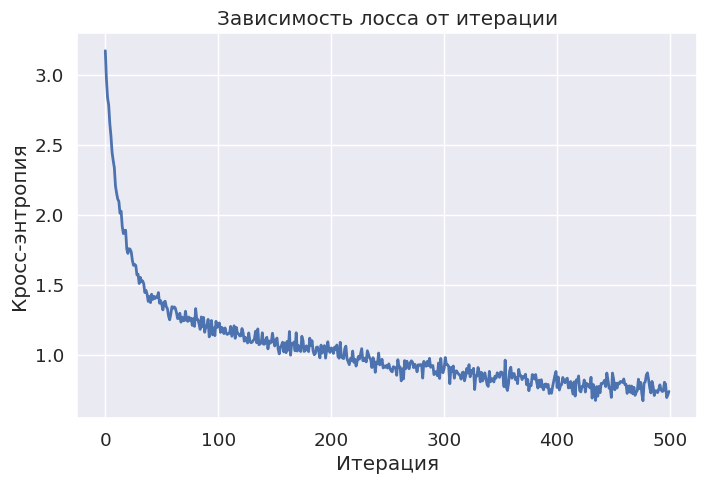

In [ ]:
model.train()

losses_history = []  # массив для истории обучения

for epoch in range(EPOCHS):
    # Обнуляем градиенты
    optimizer.zero_grad()

    # Создаём батч последовательности
    src, tgt_in, tgt_out = generate_batch(BATCH_SIZE, MAX_LEN)

    # Forward pass
    output = model(src, tgt_in) # [batch, seq_len, vocab_size]

    # Подсчёт лосса
    loss = criterion(output.reshape(-1, TGT_VOCAB_SIZE), tgt_out.view(-1))

    # Шаг оптимизатора
    loss.backward()
    optimizer.step()

    losses_history.append(loss.item())

    # Визуализация
    if (epoch + 1) % 50 == 0:
        clear_output()
        plt.figure(figsize=(8, 5))
        plt.plot(losses_history, lw=2)
        plt.ylabel('Кросс-энтропия')
        plt.xlabel('Итерация')
        plt.title('Зависимость лосса от итерации')
        plt.show()

Теперь протестируем обученную модель. Напишем функцию для предсказания последовательности.

In [ ]:
def translate(model: Transformer, input_seq: list[int]) -> list[int]:
    """
    Генерирует перевод (декодированную последовательность) для входной последовательности.

    Выполняет пошаговое декодирование с использованием обученной модели трансформера.

    Args:
        model: Обученная модель трансформера.
        input_seq: Входная последовательность токенов.

    Returns:
        Список токенов выходной последовательности без старт-токена.
    """
    model.eval()
    src = torch.tensor(input_seq).unsqueeze(0).to(device)
    src_mask = (src != 0).unsqueeze(1).unsqueeze(2)

    with torch.no_grad():
        enc_output = model.encode(src, src_mask)

        # 2. Начинаем со специального токена (например, 1 - наш START_TOKEN)
        # В нашей задаче инверсии мы использовали 1 как заглушку в generate_batch
        tgt = torch.ones(1, 1).long().to(device)

        for _ in range(len(input_seq)):
            # Генерируем маски для текущего состояния
            _, tgt_mask = model.generate_mask(src, tgt)

            # Декодируем
            out = model.decode(tgt, enc_output, src_mask, tgt_mask)
            logits = model.fc_out(out[:, -1, :])  # берем только последний временной шаг

            next_token = logits.argmax(dim=-1).item()
            tgt = torch.cat([tgt, torch.tensor([[next_token]]).to(device)], dim=1)

            if next_token == 0:  # если встретили PAD (конец), останавливаемся
                break

    return tgt.squeeze().tolist()[1:]  # убираем первый старт-токен


Посмотрим на результат работы модели.

In [ ]:
test_seq = [1, 2, 3, 4, 5]  # входная последовательность
print(f"Вход:\t{test_seq}")

predicted = translate(model, test_seq)
out_seq = predicted[:len(test_seq)]  # мы ожидаем срез такой же длины, как вход
print(f"Выход:\t{out_seq}")

Вход:	[1, 2, 3, 4, 5]
Выход:	[5, 4, 3, 2, 1]


Посмотрим на другом примере.

In [ ]:
test_seq = [5, 19, 3, 9, 15]  # входная последовательность
print(f"Вход:\t{test_seq}")

predicted = translate(model, test_seq)
out_seq = predicted[:len(test_seq)]  # мы ожидаем срез такой же длины, как вход
print(f"Выход:\t{out_seq}")

Вход:	[5, 19, 3, 9, 15]
Выход:	[15, 9, 3, 5, 19]


## 3. Дообучение BERT

[Transfer Learning](https://arxiv.org/abs/1808.01974) &mdash; это процесс дообучения на *новых данных* какой-либо нейросети, предобученной до этого на других данных.

Мы уже знакомились с этой техникой на примере картинок, попробуем теперь применить её к текстовым данным.

### 3.1. BERT

`BERT` (`Bidirectional Encoder Representations from Transformers`) &mdash; модель, предобученная на больших корпусах текстов решать несколько NLP задач, архитектурно &mdash; энкодер трансформера.

Как и модели из CV `BERT` можно использовать как:

* **Feature Extractor** &mdash; используем модель как средство для извлечения признаков из текстовых данных. Полученные признаки можно использовать, например, для обучения другой модели.
* **Fine Tuning** &mdash; дообучение модели под конкретную задачу: classification, entity recognition, question answering и тд.  
* **Использовать предобученную модель "из коробки"**  

Мы будем использовать библиотеку [`transformers`](https://huggingface.co/transformers/index.html), содержащую многие предобученные Transformer-based модели.

### 3.2. Загрузка и обработка данных

Будем использовать датасет для бинарной классификации фильмов по их эмоциональной окраске [`IMDB Dataset of 50K Movie Reviews` ](https://www.kaggle.com/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews). Для его загрузки используем функцию `load_dataset` из библиотеки `datasets` от HuggingFace.

In [ ]:
train_dataset, test_dataset = load_dataset("imdb", split=["train", "test"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Получаем объекты класса `Dataset`.

In [ ]:
train_dataset, test_dataset

(Dataset({
     features: ['text', 'label'],
     num_rows: 25000
 }),
 Dataset({
     features: ['text', 'label'],
     num_rows: 25000
 }))

Приведем данные к необходимому формату.

Добавим специальные токены `[CLS]` и `[SEP]` в начало и конец предложения соответственно. Они необходимы для корректной работы `BERT`. На самом деле процесс добавления специальных токенов можно через автоматизировать через токенизатор. Мы сделаем это вручную, показав пример работы метода `.map(...)` у датасета.

`[SEP]` &mdash; токен, разделяющий предложения или определяющий конец предложения

`[CLS]` &mdash; токен, который ставится в начале предложения и используется для задачи классификации

*Пример для задачи Next Sentence Prediction:*

`[CLS] предложение A [SEP] предложение B [SEP]`



Скрытое состояние, относящееся к метке `[CLS]`, будет содержать в себе аггрегированное представление всего предложения, которое дальше будет использоваться для классификации. Токен `[SEP]` был использован для разделения предложений в классической задаче из оригинальной статьи, позднее его практически перестали использовать

In [ ]:
def add_special_tokens(example):
    """
    Добавляет специальные токены в текст.

    Оборачивает текст токенами начала ([CLS]) и конца ([SEP]).

    Args:
        example: Словарь с ключом "text", содержащим строку текста.

    Returns:
        Обновлённый словарь примера с добавленными специальными токенами.
    """
    example["text"] = "[CLS]" + example["text"] + "[SEP]"
    return example


train_dataset = train_dataset.map(add_special_tokens)
test_dataset = test_dataset.map(add_special_tokens)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

С помощью токенизатора для BERT'а превратим наши текстовые данные в набор токенов из словаря предобученной модели.

`BertTokenizer` принимает на вход:

* `vocab_file` &mdash; словарь. В нашем случае мы используем словарь предобученной модели  `bert-base-uncased`, так как в последствии будем дообучать предобученную модель.

  `bert-base-uncased` &mdash; это "base" версия `BERTa`, где есть только буквы в нижнем регистре ("uncased"). В оригинальной статье рассказывается про две модели: "base" vs "large".

  [Здесь](https://huggingface.co/transformers/pretrained_models.html) можно ознакомиться со списком доступных предобученных моделей.

* `do_lower_case` &mdash; приводить ли вход к нижнему регистру;

In [ ]:
tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased",
    do_lower_case=True,
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Посмотрим на пример токенизации через метод `.tokenize(...)`.

In [ ]:
example_sent = "He remains characteristically confident and optimistic."
example_sent = "[CLS] " + example_sent + " [SEP]"
print("Предложение:", example_sent)
print("Предложение после токенизации:", tokenizer.tokenize(example_sent))

Предложение: [CLS] He remains characteristically confident and optimistic. [SEP]
Предложение после токенизации: ['[CLS]', 'he', 'remains', 'characteristic', '##ally', 'confident', 'and', 'optimistic', '.', '[SEP]']


Слово `characteristically` не встречается в словаре, однако существует способ разбить его на подслова, каждое из которых встречается в словаре. Подслова обозначаются специальными символами `##`. Если такого разбиения на подслова не существует, то слово целиком заменяется на токен `[UNK]`.

Токенизировать, а затем переводить токены в набор id-шников не очень удобно. У токенизатора переопределен метод `__call__`, который позволяет токенизировать и сразу подготовить текстовый пример на вход модели.

In [ ]:
output = tokenizer(
    example_sent,
    padding="max_length",
    truncation=True,
    max_length=256,
    add_special_tokens=False
)
output

{'input_ids': [101, 2002, 3464, 8281, 3973, 9657, 1998, 21931, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Декодируем текст обратно.

In [ ]:
tokenizer.decode(output["input_ids"])

'[CLS] he remains characteristically confident and optimistic. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [

Как видим, помимо `input_ids`, которые отправятся на вход модели, у нас так же имеется `attention_mask`. Это маска внимания, она необходима для того, чтобы не считать self-attention для токенов паддинга. Также в зависимости от модели могут быть `token_type_ids` &mdash; некоторые модели используют для задачи **NSP**.

Как вы можете заметить, во время вызовва токенизатор мы указали ряд параметров:

* `padding` &mdash; уже на этапе токенизации мы могли бы дополнить паддингом до максимальной длины все наши последовательности.
* `truncation` &mdash; позволяет обрезать слишком длинные последовательности.
* `max_length` &mdash; длина, до которой нужно сделать паддинг или обрезать последовательность.
* `add_special_tokens` &mdash; добавлять ли спец. токены, мы это сделали заранее.

Токенизируем наши датасеты, снова используя метод `.map(..)`. Обрежем все тексты до длины в 512 токенов, так как BERT работает со входными данными одной длины.

In [ ]:
train_dataset = train_dataset.map(
    lambda example: tokenizer(
        example["text"],
        truncation=True,
        max_length=512,
        add_special_tokens=False
    ),
    batched=True
)

test_dataset = test_dataset.map(
    lambda example: tokenizer(
        example["text"],
        truncation=True,
        max_length=512,
        add_special_tokens=False
    ),
    batched=True
)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Мы заранее обрезали слишком большие тексты до длины в 512 токенов. Однако это не совсем верно. Построим гистограмму распределения длин символов и посмотрим на возникающую проблему.

<Figure size 1500x500 with 0 Axes>

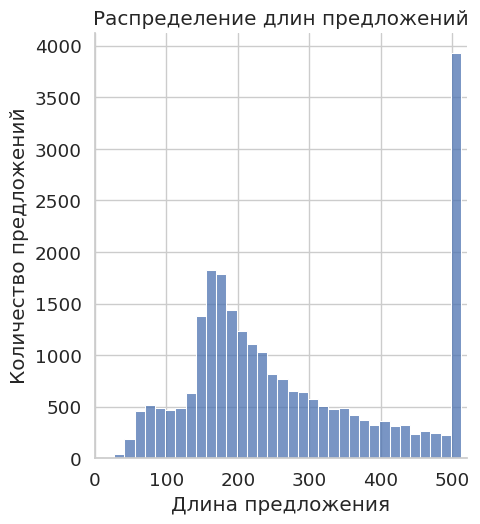

In [ ]:
lens = [len(x["input_ids"]) for x in train_dataset]

with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,5))

    sns.displot(lens)
    plt.xlim([0, 520])
    plt.xlabel("Длина предложения")
    plt.ylabel("Количество предложений")
    plt.title("Распределение длин предложений")

    plt.show()

Получили завышенное в 512 распределение длин. Это произошло, так как существует большое количество текстов с длиной, большей 512 символов.

Так как в рамках семинара мы работаем с моделью [`google-bert/bert-base-uncased`](https://huggingface.co/google-bert/bert-base-uncased), которая рассчитана на последовательности длиной не более 512, согласимся с таким допущением. Чуть более грамотно было бы использовать модель с бóльшим контекстом.

Избавимся от ненужного поля `text`.

In [ ]:
train_dataset = train_dataset.remove_columns("text")
test_dataset = test_dataset.remove_columns("text")

Выделим часть данных для валидации, используя встроенный метод `.train_test_split(...)`.

In [ ]:
splitted_dataset = train_dataset.train_test_split(test_size=0.1)

train_dataset = splitted_dataset["train"]
validation_dataset = splitted_dataset["test"]

Зададим даталоадеры.

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer)

train_loader = DataLoader(train_dataset,
                          batch_size=16,
                          shuffle=True,
                          collate_fn=data_collator)

validation_loader = DataLoader(validation_dataset,
                               batch_size=16,
                               shuffle=False,
                               collate_fn=data_collator)

### 3.3. Обучение модели

Данные подготовлены, пришло время обучения модели.

Мы хотим изменить предобученный `BERT` так, чтобы он выдавал метки для классификации текстов, а затем дообучить его на наших данных. Для этого вы можете взять готовую модификацию `BERTа` для классификации из библиотеки `transformers`: [`BertForSequenceClassification`](https://huggingface.co/transformers/_modules/transformers/modeling_bert.html#BertForSequenceClassification). Это обертка над обычным `BERT` с добавленным линейным слоем для классификации. Альтернативно, можно взять стандартную предобученную модель [`BertModel`](https://huggingface.co/transformers/model_doc/bert.html#bertmodel) и добавить слой для классификации самим. Мы попробуем оба подхода.

В библиотеке [`transformers`](https://huggingface.co/transformers/model_doc/bert.html) есть аналогичные модели для разных NLP задач: `BertForNextSentencePrediction`, `BertForMaskedLM` и тд. Все они построены на основе одной и той же архитектуры и различаются только верхними слоями.

Мы будем использовать предобученную модель `bert-base-uncased`. `bert-base-uncased` &mdash; это "base" версия `BERTa`, где есть только буквы в нижнем регистре ("uncased"). В оригинальной статье рассказывается про две модели: "base" vs "large".

[Здесь](https://huggingface.co/transformers/pretrained_models.html) можно ознакомиться со списком доступных предобученных моделей.

In [ ]:
class OurBertForSequenceClassification(nn.Module):
    """
    Обёртка над BERT для задачи классификации текстов.

    Использует представление CLS-токена для предсказания класса.
    """

    def __init__(self, num_labels: int) -> None:
        """
        Инициализирует модель классификации на основе BERT.

        Args:
            num_labels: Количество классов для классификации.

        Returns:
            None
        """
        super(OurBertForSequenceClassification, self).__init__()
        # загрузим модель из HF
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.drop = nn.Dropout(p=0.1)

        # линейный слой для преобразования выхода в вероятности классов
        self.fc = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor
    ) -> torch.Tensor:
        """
        Выполняет прямой проход модели.

        Args:
            input_ids: Тензор идентификаторов токенов формы [batch_size, seq_len].
            attention_mask: Маска внимания формы [batch_size, seq_len].

        Returns:
            Логиты классов формы [batch_size, num_labels].
        """
        # в bert подается input и attention mask
        output = self.bert(
          input_ids=input_ids,
          attention_mask=attention_mask
        )
        # возьмем CLS токен
        output = output.last_hidden_state[:, 0, :]
        output = self.drop(output)
        return self.fc(output)


При дообучении BERTа можно пользоваться всеми стандартными техниками: постепенной разморозкой слоёв, различными стратегиями работы с learning rate, чтобы сохранить "хорошие" веса в нижних слоях и ускорить обучение.

In [ ]:
our_model = OurBertForSequenceClassification(num_labels=2)
standard_model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Удостоверимся, что архитектуры [`BertForSequenceClassification`](https://huggingface.co/transformers/_modules/transformers/modeling_bert.html#BertForSequenceClassification) и [`BertModel`](https://huggingface.co/transformers/model_doc/bert.html#bertmodel) с `fc`-слоем идентичны:

In [ ]:
our_model

OurBertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps

In [ ]:
standard_model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

`BertForSequenceClassification` может опционально вернуть loss при вызове метода `forward`. Для включения опции возвращения лосса нужно передать методу `forward` таргеты `labels`.

``` python
# в данном случае модель возвращает только логиты
model_output = model(X_batch)
logits = model_output.logits
loss = criterion(logits, y_batch)
loss.backward()
```

``` python
# в данном случае модель возвращает и лосс и логиты
model_output = model(X_batch,labels=y_batch)
logits = model_output.logits
loss = model_output.loss
loss.backward()
```

Если `num_labels == 1`, то в качестве лосса будет использован `nn.MSELoss` (регрессия).

Если `num_labels > 1` &mdash; `nn.CrossEntropyLoss` (классификация).

В дальнейшем будем обучать `our_model`.

In [ ]:
our_model = our_model.to(device)
optimizer = torch.optim.AdamW(our_model.parameters(), lr=2e-5)

Старый и уже знакомый пайплайн обучения.

In [ ]:
def train(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    train_batch_gen,
    val_batch_gen,
    num_epochs: int = 50
) -> tuple[nn.Module, dict]:
    """
    Обучает модель и вычисляет метрики на обучающей и валидационной выборках.

    Выполняет цикл обучения по эпохам, сохраняя значения лосса и accuracy
    для train и validation.

    Args:
        model: Обучаемая модель.
        optimizer: Оптимизатор для обновления весов модели.
        criterion: Функция потерь.
        train_batch_gen: Генератор батчей обучающей выборки.
        val_batch_gen: Генератор батчей валидационной выборки.
        num_epochs: Количество эпох обучения.

    Returns:
        Кортеж из:
        - обученной модели,
        - словаря с историей метрик обучения и валидации.
    """

    history = defaultdict(lambda: defaultdict(list))

    global_step = 0
    iter_losses = []

    for epoch in range(num_epochs):
        train_loss = 0
        train_acc = 0
        val_loss = 0
        val_acc = 0

        start_time = time.time()

        model.train(True) # устанавливаем поведение dropout / batch_norm  в обучение

        # На каждой "эпохе" делаем полный проход по данным
        for batch in train_batch_gen:
            global_step += 1

            # Обучаемся на батче (одна "итерация" обучения нейросети)
            logits = model(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device)
            )
            loss = criterion(logits, batch["labels"].to(device))
            # backward
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            # Cохраним лосс и посчитаем метрики
            train_loss += loss.item()
            iter_losses.append(loss.item())
            y_pred = logits.max(1)[1].detach().cpu().numpy()
            train_acc += np.mean(batch["labels"].numpy() == y_pred)

            # Визуализация процесса обучения
            if global_step % 100 == 0:
                clear_output()
                plt.figure(figsize=(8, 5))
                plt.plot(iter_losses, lw=2)
                plt.ylabel('Кросс-энтропия')
                plt.xlabel('Итерация')
                plt.title('Зависимость лосса от итерации')
                plt.show()

        # Подсчитываем лоссы и сохраням в "историю"
        train_loss /= len(train_batch_gen)
        train_acc /= len(train_batch_gen)
        history['loss']['train'].append(train_loss)
        history['acc']['train'].append(train_acc)

        model.train(False) # устанавливаем поведение dropout / batch_norm  в тестирование

        # Полный проход по валидации
        for batch in tqdm(val_batch_gen, desc="evaluation"):
            # При использовании .no_grad() модель не будет считать и хранить градиенты.
            # Это ускорит процесс предсказания меток для валидационных данных.
            with torch.no_grad():
                logits = model(
                    input_ids=batch["input_ids"].to(device),
                    attention_mask=batch["attention_mask"].to(device)
                )
                loss = criterion(logits, batch["labels"].to(device))

            val_loss += loss.item()

            # применяем функцию max к каждому логиту из батча
            # функция max возвращает две величины: значения и индексы
            # выбираем индексы
            y_pred = logits.max(1)[1].detach().cpu().numpy()
            val_acc += np.mean(batch["labels"].numpy() == y_pred)

        # Подсчитываем лоссы и сохраням в "историю"
        val_loss /= len(val_batch_gen)
        val_acc /= len(val_batch_gen)
        history['loss']['val'].append(val_loss)
        history['acc']['val'].append(val_acc)

        # Печатаем результаты после каждой эпохи
        print("Epoch {} of {} took {:.3f}s".format(
            epoch + 1, num_epochs, time.time() - start_time))
        print("  training loss (in-iteration): \t{:.6f}".format(train_loss))
        print("  validation loss (in-iteration): \t{:.6f}".format(val_loss))
        print("  training accuracy: \t\t\t{:.2f} %".format(train_acc * 100))
        print("  validation accuracy: \t\t\t{:.2f} %".format(val_acc * 100))

    return model, history


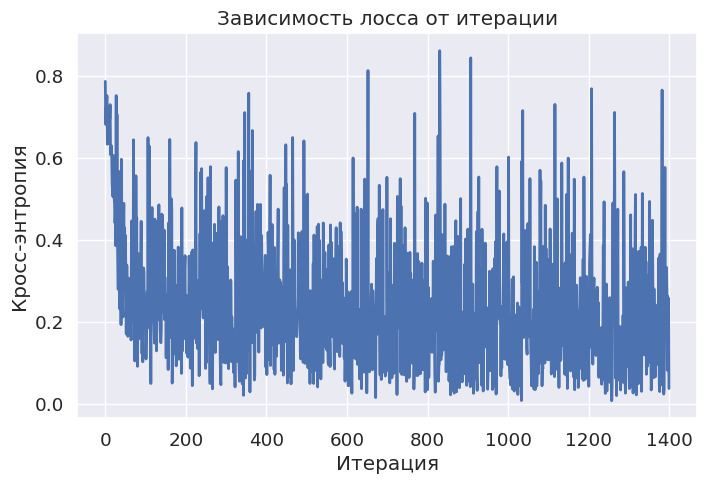

evaluation:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1 of 1 took 2057.340s
  training loss (in-iteration): 	0.238613
  validation loss (in-iteration): 	0.160444
  training accuracy: 			90.49 %
  validation accuracy: 			94.47 %


In [ ]:
criterion = nn.CrossEntropyLoss()

our_model, history = train(
    our_model, optimizer, criterion,
    train_loader, validation_loader,
    num_epochs=1
)

Одна эпоха занимает примерно 30 минут.

Оценим качество на тестовой выборке:

In [ ]:
test_loader = DataLoader(test_dataset,
                         batch_size=16,
                         shuffle=False,
                         collate_fn=data_collator)

In [ ]:
our_model.eval()
test_preds, test_labels = [], []

for batch in tqdm(test_loader, desc="testing"):
    with torch.no_grad():
        logits = our_model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device)
        )

    y_pred = logits.max(1)[1].detach().cpu().numpy()
    test_preds.extend(y_pred)
    test_labels.extend(batch["labels"].numpy())

testing:   0%|          | 0/1563 [00:00<?, ?it/s]

In [ ]:
test_accuracy = accuracy_score(test_labels, test_preds) * 100
test_precision = precision_score(test_labels, test_preds) * 100
test_recall = recall_score(test_labels, test_preds) * 100

print(f"Accuracy: {test_accuracy:.2f}%, Precision: {test_precision:.2f}%, Recall: {test_recall:.2f}%")

Accuracy: 93.42%, Precision: 93.20%, Recall: 93.68%


Дообучив предобученную модель всего на одной эпохе, получили достаточно хорошее качество предсказания.

Напомним, что на первом семинаре по NLP с использованием свёрточной сети была получена более низкая точность классификации &mdash; около 87%.

### 3.4. Transformers Trainer

Попробуем воспользоваться [`Trainer`](https://huggingface.co/docs/transformers/main_classes/trainer)-ом и библиотеки `transformers`. Класс `Trainer` предоставляет очень гибкое API для полного обучения моделей, избавляя вас от необходимости писать кастомный training-loop. `Trainer` обладает широкими возможностями для легкой кастомизации цикла обучения. Изучение всех особенностей этого класса потребовало бы от нас много времени, поэтому мы посмотрим на минимальный пример. Более подробно с возможностями `Trainer`'a вам будет предложено познакомиться в домашнем задании.


In [ ]:
from transformers import TrainingArguments, Trainer

# зададим параметры обучения
training_args = TrainingArguments(
    output_dir="./results",  # папка для сохранения предсказаний и чекпоинтов моделей
    num_train_epochs=1,  # кол-во эпох обучения
    eval_strategy="steps",  # или "epoch"
    eval_steps=500,  # каждые N шагов (если eval_strategy="steps")
    logging_steps=500,  # чтобы лоссы печатались
    report_to="none"  # не будем использовать продвинутые способы логгирования
)

Создадим объект класса `Trainer` и обучим модель.

In [ ]:
trainer = Trainer(
    model=standard_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    tokenizer=tokenizer,
)

/tmp/ipython-input-1397821594.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Step,Training Loss,Validation Loss
500,0.404700,0.464341
1000,0.335900,0.355366
1500,0.306100,0.279548
2000,0.282800,0.245841
2500,0.272000,0.224383


TrainOutput(global_step=2813, training_loss=0.3123343664685306, metrics={'train_runtime': 2544.575, 'train_samples_per_second': 8.842, 'train_steps_per_second': 1.105, 'total_flos': 5565581987364720.0, 'train_loss': 0.3123343664685306, 'epoch': 1.0})

Снова посчитаем качество на тестовой выборке. Обратите внимание, т.к. мы используем `BertForSequenceClassification` из `transformers`, код претерпел значительные изменения.

In [ ]:
standard_model.eval()
test_preds, test_labels = [], []

for batch in tqdm(test_loader, desc="testing"):
    with torch.no_grad():
        model_output = standard_model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device)
        )
        logits = model_output.logits

    y_pred = logits.max(1)[1].detach().cpu().numpy()
    test_preds.extend(y_pred)
    test_labels.extend(batch["labels"].numpy())

testing:   0%|          | 0/1563 [00:00<?, ?it/s]

In [ ]:
test_accuracy = accuracy_score(test_labels, test_preds) * 100
test_precision = precision_score(test_labels, test_preds) * 100
test_recall = recall_score(test_labels, test_preds) * 100

print(f"Accuracy: {test_accuracy:.2f}%, Precision: {test_precision:.2f}%, Recall: {test_recall:.2f}%")

Accuracy: 93.43%, Precision: 93.02%, Recall: 93.90%


Используя `Trainer`, мы получили качество, сопоставимое с классическим training-loop.